# PhenoVision: plant phenology (flower / fruit) detection from field photographs

**Paper:** Dinnage, R., Grady, E., Neal, N., Deck, J., Denny, E., Walls, R., Seltzer, C., Guralnick, R., & Li, D. (2025). *PhenoVision: A framework for automating and delivering research-ready plant phenology data from field images.* bioRxiv 2024.10.10.617505; published in **Methods in Ecology and Evolution** 16:1763–1780, doi:[10.1111/2041-210X.14346](https://doi.org/10.1111/2041-210X.14346).

**Author code:** https://github.com/Phenobase/phenovision (pinned commit `071faa4`) · **Published model:** https://huggingface.co/phenobase/phenovision (v1.1.0, MIT license, HF DOI 10.57967/hf/7952)

## Purpose and exact scope
This notebook reproduces the **minimal inference path** documented by the authors in the Hugging Face model card: load the published PhenoVision v1.1.0 weights, run them on **two pinned, CC-licensed iNaturalist plant photographs**, convert the sigmoid outputs into **Detected / Not Detected / Equivocal** calls using the authors' companion threshold/buffer file (`final_buffer_params.csv`), and compare the model calls with the **human reference phenology annotations** on those observations.

- **This is a partial demonstration on 2 images.** It does **not** verify the paper's dataset-level accuracies (98.0% flower / 97.0% fruit buffer-filtered), the 1.5M-image training, or the 53.5M-image labeling campaign — those are out of scope.
- Training, dataset construction, and large-scale labeling are not exercised.

**Japanese summary (日本語の要約):**
このノートブックは、PhenoVision v1.1.0（ViT-Large/16）の公開重みを Hugging Face から読み込み、ピン留めした2枚の iNaturalist 植物写真（CCライセンス）に対して推論を実行します。sigmoid 出力を、著者提供のしきい値・バッファファイル `final_buffer_params.csv` で **Detected / Not Detected / Equivocal** に変換し、iNaturalist の人手アノテーション（参照ラベル）と比較します。学習や大規模ラベリングは対象外で、2例の部分デモンストレーションです。

## Runtime selection (ランタイム選択)
- **Recommended: T4 GPU** (Runtime ▸ Change runtime type ▸ T4 GPU). Inference is a single-image ViT-Large forward — CPU also works (faithful, a few seconds slower); the notebook auto-detects the device.
- Expected duration: ~5–10 min total (≈1.2 GB model download dominates). Downloads: model weights (~1.2 GB) + 2 small photos + 2 small CSVs.

## 1. Environment check (環境確認)
This cell imports the required libraries and prints versions plus the detected device. PhenoVision is used exactly as the authors ship it on the Hugging Face Hub: a `transformers` `ViTForImageClassification` with its `ConvNextImageProcessor`. The authors' model card notes that `torchvision` is needed by the image processor in `transformers` v5+, so we check it is importable. No packages are installed: Colab's preinstalled stack satisfies all requirements (verified on the validation date recorded at the end of this notebook).
このセルは必要ライブラリのバージョンとデバイス（T4 GPU または CPU）を確認します。Colab 標準の torch / transformers / torchvision をそのまま使用します。

In [ ]:
import sys, torch, torchvision, transformers
import pandas as pd

print("python:", sys.version.split()[0])
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__, "| transformers:", transformers.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU (faithful path; T4 GPU is the recommended runtime).")
print("device:", DEVICE)

python: 3.13.15
torch: 2.11.0+cu130 | torchvision: 0.26.0+cu130 | transformers: 5.18.0
GPU: Tesla T4
device: cuda


## 2. Load the published PhenoVision v1.1.0 model (公開重みの読み込み)
We download the authors' published model from the Hugging Face Hub, **pinned to revision `965b18e6b678abeabcf29c369eb480edcb0c0f92`** (the v1.1.0 weights verified for this run; pinned so future repo updates cannot silently change this demonstration). The checkpoint is ViT-Large/16 (~304M parameters, fp32 ≈ 1.2 GB) with a 2-label multi-label head: `id2label = {0: fruit, 1: flower}`. The label order — **index 0 = FRUIT, index 1 = FLOWER** — is documented in the authors' model card and matches `config.json`. The download may take a few minutes.
著者の公開モデルを Hugging Face からリビジョン固定で読み込みます（約1.2 GB、ViT-L/16、出力は [fruit, flower] の順）。数分かかることがあります。

In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor

HF_REPO = "phenobase/phenovision"
HF_REVISION = "965b18e6b678abeabcf29c369eb480edcb0c0f92"  # v1.1.0 weights verified 2026-10-08

processor = AutoImageProcessor.from_pretrained(HF_REPO, revision=HF_REVISION)
model = AutoModelForImageClassification.from_pretrained(HF_REPO, revision=HF_REVISION)
model.eval()  # inference mode: disable training-time behavior
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.1f} M")
print("id2label:", model.config.id2label)
assert model.config.id2label == {0: "fruit", 1: "flower"}, "unexpected label mapping"

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

parameters: 303.3 M
id2label: {0: 'fruit', 1: 'flower'}


## 3. Retrieve the pinned sample photos and their human reference annotations (サンプル画像と参照アノテーション)
The two samples are public iNaturalist research-grade observations of *Helianthus annuus* (common sunflower) with permissive licenses and **human "Flowers and Fruits" phenology annotations** (controlled term 12; values: 13 = Flowers, 14 = Fruits or Seeds):

| Observation | Photo (open-data S3) | License | Human reference annotation |
|---|---|---|---|
| [61287321](https://www.inaturalist.org/observations/61287321) | 98056702 | CC-BY | Flowers |
| [315954219](https://www.inaturalist.org/observations/315954219) | 570816094 | CC-BY (obs CC0) | Flowers **and** Fruits or Seeds |

This cell fetches only **observation metadata (JSON)** from the public `api.inaturalist.org` endpoint and verifies the expected annotations are present; the photo **bytes** are downloaded in the next section. The first observation is annotated "Flowers" only, so it also probes the fruit head's absence behaviour; the second is the multi-label case (both traits annotated).
サンプルは iNaturalist の公開観察（CC-BY）。まず観察メタデータ（JSON）を取得し、期待した人手アノテーション（term 12 "Flowers and Fruits"）が付いていることを検証します。

In [ ]:
import requests

INAT_API = "https://api.inaturalist.org/v1/observations"
SAMPLES = {
    61287321:   {"expected_ann": {13}},          # Flowers
    315954219:  {"expected_ann": {13, 14}},       # Flowers and Fruits or Seeds
}

for obs_id, meta in SAMPLES.items():
    r = requests.get(f"{INAT_API}/{obs_id}", timeout=60)
    r.raise_for_status()
    obs = r.json()["results"][0]
    photo = obs["photos"][0]
    meta["taxon"] = (obs.get("taxon") or {}).get("name")
    meta["obs_license"] = obs.get("license_code")
    meta["photo_license"] = photo.get("license_code")
    # square -> medium keeps the download small; the processor resizes to 224 px anyway
    meta["photo_url"] = photo["url"].replace("/square.", "/medium.")
    anns = {a["controlled_value_id"] for a in obs.get("annotations", [])
            if a.get("controlled_attribute_id") == 12}
    meta["annotations"] = sorted(anns)
    assert anns == meta["expected_ann"], f"obs {obs_id}: annotation {anns} != expected {meta['expected_ann']}"
    print(f"obs {obs_id}: {meta['taxon']} | obs lic {meta['obs_license']} | photo lic {meta['photo_license']}")
    print(f"  reference annotations (term 12): {sorted(anns)} -> "
          + ", ".join({13: 'Flowers', 14: 'Fruits or Seeds'}[a] for a in sorted(anns)))
    print(f"  photo: {meta['photo_url']}")

obs 61287321: Helianthus annuus | obs lic cc-by | photo lic cc-by
  reference annotations (term 12): [13] -> Flowers
  photo: https://inaturalist-open-data.s3.amazonaws.com/photos/98056702/medium.jpeg


obs 315954219: Helianthus annuus | obs lic cc0 | photo lic cc-by
  reference annotations (term 12): [13, 14] -> Flowers, Fruits or Seeds
  photo: https://inaturalist-open-data.s3.amazonaws.com/photos/570816094/medium.jpg


## 4. Input preview with reference annotations (入力画像のプレビュー)
Before running the model, we display the actual sample inputs with their **human reference annotations** clearly labeled in the titles. These are the real photographs the reproduction handles (downloaded from the iNaturalist open-data S3 bucket inside this Colab runtime).
モデル実行前に、実際の入力画像を人手の参照アノテーション付きで表示します。

obs 61287321: downloaded 73 KiB, size (500, 400)


obs 315954219: downloaded 184 KiB, size (376, 500)


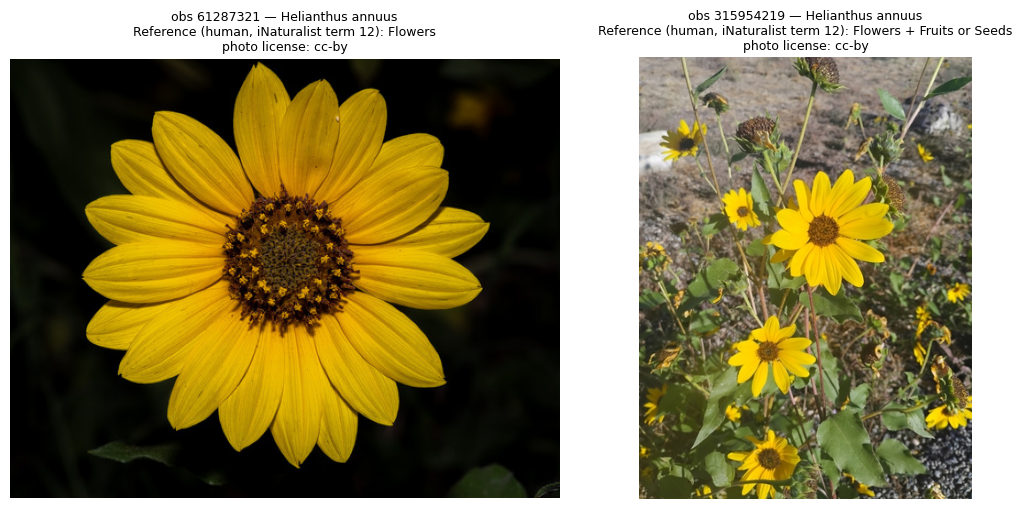

In [ ]:
import io
from PIL import Image
import matplotlib.pyplot as plt

for obs_id, meta in SAMPLES.items():
    resp = requests.get(meta["photo_url"], timeout=120)
    resp.raise_for_status()
    img = Image.open(io.BytesIO(resp.content)).convert("RGB")
    meta["image"] = img
    print(f"obs {obs_id}: downloaded {len(resp.content)/1024:.0f} KiB, size {img.size}")

ref_names = {13: "Flowers", 14: "Fruits or Seeds"}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (obs_id, meta) in zip(axes, SAMPLES.items()):
    ax.imshow(meta["image"])
    refs = " + ".join(ref_names[a] for a in meta["annotations"])
    ax.set_title(f"obs {obs_id} — {meta['taxon']}\nReference (human, iNaturalist term 12): {refs}\nphoto license: {meta['photo_license']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/phenovision_inputs.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. PhenoVision inference (推論の実行)
Following the authors' model card usage snippet exactly: preprocess each image with the shipped processor, take the 2 logits, and apply a **sigmoid** (multi-label — the two heads are independent). Output order is **[fruit, flower]** (config `id2label`). `torch.no_grad()` disables gradients; this is the authors' published inference path with no algorithmic changes.
著者のモデルカードの手順どおり：プロセッサで前処理し、2つのロジットに sigmoid を適用します（マルチラベル、出力順は [fruit, flower]）。算法の変更はありません。

In [ ]:
@torch.no_grad()
def phenovision_probs(img: Image.Image) -> dict:
    """Return sigmoid probabilities {'fruit': p, 'flower': p} following the authors' snippet."""
    inputs = processor(images=img, return_tensors="pt").to(DEVICE)
    logits = model(**inputs).logits[0]          # shape [2], order [fruit, flower]
    probs = torch.sigmoid(logits)
    return {"fruit": probs[0].item(), "flower": probs[1].item()}

for obs_id, meta in SAMPLES.items():
    meta["probs"] = phenovision_probs(meta["image"])
    p = meta["probs"]
    print(f"obs {obs_id}: flower p = {p['flower']:.3f} | fruit p = {p['fruit']:.3f}")

obs 61287321: flower p = 1.000 | fruit p = 0.000
obs 315954219: flower p = 0.998 | fruit p = 0.057


## 6. Threshold and buffer parameters from the authors' companion file (しきい値・バッファの取得)
Raw probabilities become research-grade calls via the authors' tuned thresholds and **uncertainty buffers** (paper §"Model Calibration and Tuning"; shipped as `final_buffer_params.csv` on the Hugging Face repo, revision-pinned like the weights). The rule from the model card:

- p **above** threshold + buffer upper → **Detected** (high certainty)
- p **below** threshold − buffer lower → **Not Detected** (high certainty)
- p **within** the buffer zone → **Equivocal** (excluded from research-quality outputs)

We download the CSV and first print it verbatim so the actual schema is visible (it is a data-side artifact, not hard-coded here).
著者提供の `final_buffer_params.csv` をリビジョン固定でダウンロードし、まず中身をそのまま表示します（しきい値をハードコードしないため）。

In [ ]:
import urllib.request

CSV_URL = f"https://huggingface.co/{HF_REPO}/resolve/{HF_REVISION}/final_buffer_params.csv"
urllib.request.urlretrieve(CSV_URL, "/content/final_buffer_params.csv")
with open("/content/final_buffer_params.csv") as f:
    print(f.read())

class,threshold,buffer_lower,buffer_upper,equivocal_lower,equivocal_upper,accuracy_cutoff,method
flower,0.48,0.32499999999999996,0.385,0.15500000000000003,0.865,0.8,overall_accuracy
fruit,0.6,0.40499999999999997,0.30500000000000005,0.195,0.905,0.8,overall_accuracy



## 7. Convert probabilities to Detected / Not Detected / Equivocal calls (判定の適用)
This cell parses the downloaded CSV into per-trait threshold/buffer values and applies the Detected / Not Detected / Equivocal rule to both samples. Results are shown in a table next to the **human reference annotations**, and exported to `/content/phenovision_calls.csv`.
CSV をパースして各クラスのしきい値・バッファを取得し、Detected / Not Detected / Equivocal を判定して参照アノテーションと並べた表にします。結果は CSV にも書き出します。

In [ ]:
params = pd.read_csv("/content/final_buffer_params.csv")
params.columns = [c.strip().lower() for c in params.columns]

def find_col(cands):
    for c in params.columns:
        if cands in c:
            return c
    raise KeyError(f"no column matching {cands} in {list(params.columns)}")

class_col = find_col("trait") if "trait" in params.columns else find_col("class")
thr_col, lo_col, up_col = find_col("threshold"), find_col("lower"), find_col("upper")
params[class_col] = params[class_col].astype(str).str.strip().str.lower()

rows = []
for obs_id, meta in SAMPLES.items():
    for trait in ["flower", "fruit"]:
        prow = params[params[class_col].str.contains(trait)]
        assert len(prow) == 1, f"expected one row for {trait}, got {len(prow)}"
        thr = float(prow.iloc[0][thr_col]); lo = float(prow.iloc[0][lo_col]); up = float(prow.iloc[0][up_col])
        p = meta["probs"][trait]
        if p > thr + up:
            call = "Detected"
        elif p < thr - lo:
            call = "Not Detected"
        else:
            call = "Equivocal"
        meta.setdefault("calls", {})[trait] = {"p": p, "thr": thr, "lo": lo, "up": up, "call": call}
        rows.append({"obs_id": obs_id, "trait": trait, "p": round(p, 3), "threshold": thr,
                     "buffer_lower": lo, "buffer_upper": up, "call": call,
                     "reference": trait.replace("flower", "Flowers") if trait == "flower" else "Fruits or Seeds",
                     "reference_value": ("annotated" if {"flower": 13, "fruit": 14}[trait] in meta["annotations"] else "not annotated")})

results = pd.DataFrame(rows)
results.to_csv("/content/phenovision_calls.csv", index=False)
results

,obs_id,trait,p,threshold,buffer_lower,buffer_upper,call,reference,reference_value
0,61287321,flower,1.000,0.48,0.325,0.385,Detected,Flowers,annotated
1,61287321,fruit,0.000,0.60,0.405,0.305,Not Detected,Fruits or Seeds,not annotated
2,315954219,flower,0.998,0.48,0.325,0.385,Detected,Flowers,annotated
3,315954219,fruit,0.057,0.60,0.405,0.305,Not Detected,Fruits or Seeds,annotated


## 8. Results: model calls vs. human reference annotations (結果の可視化)
The figure shows each input photograph with (a) the **human reference annotation** and (b) the **model's call and probability**, followed by a chart of the probabilities against each trait's threshold and equivocal buffer zone. This is a 2-image demonstration, not a validation of published accuracies.
各写真に「参照アノテーション」と「モデルの判定・確率」を重ねて表示し、確率をしきい値・バッファ帯と一緒に図示します（2例のデモであり、論文のデータセット精度の検証ではありません）。

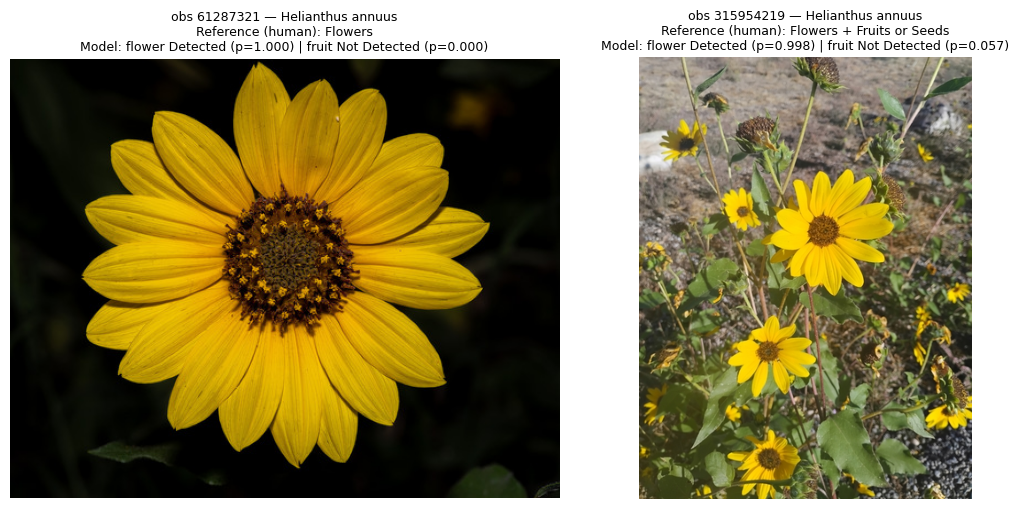

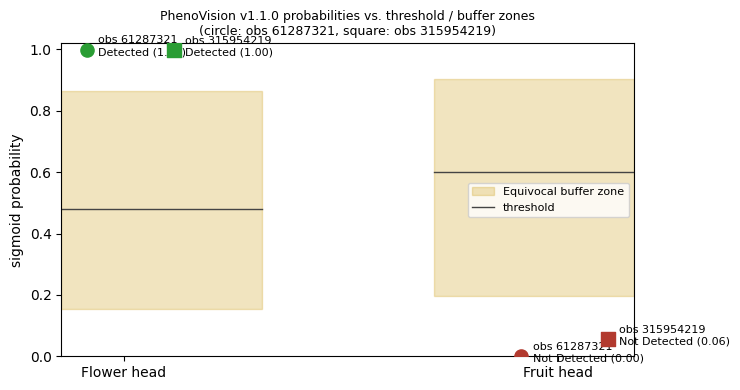

In [ ]:
call_colors = {"Detected": "#2a9d34", "Not Detected": "#b23a2f", "Equivocal": "#c99700"}

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (obs_id, meta) in zip(axes, SAMPLES.items()):
    ax.imshow(meta["image"])
    f, fr = meta["calls"]["flower"], meta["calls"]["fruit"]
    ax.set_title(f"obs {obs_id} — {meta['taxon']}\n"
                 f"Reference (human): {' + '.join(ref_names[a] for a in meta['annotations'])}\n"
                 f"Model: flower {f['call']} (p={f['p']:.3f}) | fruit {fr['call']} (p={fr['p']:.3f})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/phenovision_calls_vs_reference.png", dpi=110, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4))
xs = {"flower": (0.0, 0.35), "fruit": (0.65, 1.0)}
for i, trait in enumerate(["flower", "fruit"]):
    c = SAMPLES[61287321]["calls"][trait]
    lo, hi = c["thr"] - c["lo"], c["thr"] + c["up"]
    ax.axhspan(lo, hi, xmin=xs[trait][0], xmax=xs[trait][1], color="#c99700", alpha=0.25,
               label="Equivocal buffer zone" if i == 0 else None)
    ax.axhline(c["thr"], xmin=xs[trait][0], xmax=xs[trait][1], color="#444", lw=1,
               label="threshold" if i == 0 else None)
for marker, (obs_id, meta) in zip(["o", "s"], SAMPLES.items()):
    for j, trait in enumerate(["flower", "fruit"]):
        c = meta["calls"][trait]
        x = 0.1 + j * 0.6 + (0.12 if marker == "s" else 0.0)
        ax.scatter([x], [c["p"]], marker=marker, s=90, color=call_colors[c["call"]], zorder=3)
        ax.annotate(f"obs {obs_id}\n{c['call']} ({c['p']:.2f})", (x, c["p"]),
                    textcoords="offset points", xytext=(8, -4), fontsize=8)
ax.set_xticks([0.15, 0.75]); ax.set_xticklabels(["Flower head", "Fruit head"])
ax.set_ylabel("sigmoid probability")
ax.set_ylim(0, 1.02)
ax.set_title("PhenoVision v1.1.0 probabilities vs. threshold / buffer zones\n(circle: obs 61287321, square: obs 315954219)", fontsize=9)
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.savefig("/content/phenovision_probability_chart.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Per-family reliability from the authors' companion file (科ごとの信頼性)
The authors ship `family_stats.csv` with per-family accuracy statistics and recommend consulting it when interpreting results for a taxonomic group. Both samples are *Helianthus annuus* (family **Asteraceae**), so we display that family's row (the CSV is downloaded inside Colab).
著者提供の `family_stats.csv`（科ごとの精度統計）から、サンプルの科（ Asteraceae / キク科）の行を表示します。

In [ ]:
FAM_URL = f"https://huggingface.co/{HF_REPO}/resolve/{HF_REVISION}/family_stats.csv"
urllib.request.urlretrieve(FAM_URL, "/content/family_stats.csv")
fam = pd.read_csv("/content/family_stats.csv")
name_cols = [c for c in fam.columns if fam[c].astype(str).str.contains("Asteraceae", case=False).any()]
if name_cols:
    display(fam[fam[name_cols[0]].astype(str).str.contains("Asteraceae", case=False)])
else:
    print("Asteraceae not found; columns:", list(fam.columns))
    display(fam.head())

,family,count,equiv_prop_fl,equiv_prop_fr,.accuracy_family_flower_incl_equiv,.accuracy_family_fruit_incl_equiv,.accuracy_family_flower,.accuracy_family_fruit
32,Asteraceae,78202,0.082197,0.081788,0.898366,0.894235,0.953019,0.949899


## 10. Interpretation, limitations, and references (解釈・限界・参考文献)

**What was executed:** the authors' published v1.1.0 inference path on two CC-licensed iNaturalist photographs, with Detected / Not Detected / Equivocal calls from the authors' `final_buffer_params.csv`, compared against the human iNaturalist reference annotations shown above.

**Interpretation care (解釈上の注意):**
- **Presence-only design:** a "Not Detected" does not mean the plant has no flowers/fruits — they may simply be outside the frame (paper "Model Errors" / model card Limitations). 欠検出は「花・果実がない」ことを意味しません。
- **Version difference:** the bioRxiv/2025 paper describes the **v1.0** model (SGD; flower threshold 0.84, fruit 0.53 on its data snapshot). The published weights reproduced here are **v1.1.0** (AdamW, 2025-10-27 snapshot, thresholds from `final_buffer_params.csv`), so exact preprint metric values are not expected to match. ここで再現するのは公開済み v1.1.0 重みであり、プレプリント v1.0 のしきい値とは異なります。
- **Two images ≠ benchmark:** this demonstrates the method, not the published 98.0% / 97.0% buffer-filtered accuracies.
- **Flower-bud labels** were excluded from the authors' 2000-image validation samples, so their label accuracy is untested (flow `missing_or_unclear`).

**References:**
- Paper: bioRxiv 2024.10.10.617505 / Methods in Ecology and Evolution 16:1763–1780 (2025), doi:10.1111/2041-210X.14346
- Model: https://huggingface.co/phenobase/phenovision (v1.1.0, MIT; HF DOI 10.57967/hf/7952), revision `965b18e6b678abeabcf29c369eb480edcb0c0f92`
- Code: https://github.com/Phenobase/phenovision @ `071faa417b2835a7189b34ff75a4064cf755595f` (no LICENSE file in repo at pinned commit; the HF model is MIT)
- Samples: iNaturalist observations [61287321](https://www.inaturalist.org/observations/61287321) (CC-BY) and [315954219](https://www.inaturalist.org/observations/315954219) (CC-BY); photos from the [iNaturalist open-data AWS bucket](https://registry.opendata.aws/inaturalist-open-data/)

**Execution record:** validated on Google Colab (CPU and NVIDIA T4 GPU sessions) — see the final report for the measured validation date and hardware.